In [1]:
import sys, h5py, tifffile, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "../../src/utils")
import visium_hd

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
STOMICS_DIR = "/home/woody/iwbn/iwbn007h/spatial_data/stomics"
samples = pd.read_csv("../../src/figure4/sample_manifest.csv").set_index("name")

def load(name):
    row = samples.loc[name]
    x, y = h5py.File(row.h5ad_path)["obsm"]["spatial"][:].T
    if row.loader == "visium":
        mask, scale = visium_hd.load_visium_tissue_mask(row.h5ad_path, name)
    else:
        # _native (~450M px) crashes imshow/the kernel -- use the downsampled
        # _small mask instead, and scale spot coords to match (native shape
        # read cheaply from the tif header, no pixel data loaded)
        mask = np.load(f"{STOMICS_DIR}/{name}_ssDNA_tissue_mask_final_small.npz")["mask"]
        native_shape = tifffile.TiffFile(f"{STOMICS_DIR}/{name}_ssDNA_regist.tif").pages[0].shape
        scale = mask.shape[0] / native_shape[0]
    return mask, x * scale, y * scale

def overlay(name, bins=400):
    mask, x, y = load(name)
    H, _, _ = np.histogram2d(y, x, bins=bins, range=[[0, mask.shape[0]], [0, mask.shape[1]]])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(mask, cmap="Blues", alpha=0.5)
    ax.imshow(H > 0, cmap="Reds", alpha=0.5, extent=[0, mask.shape[1], mask.shape[0], 0])
    ax.set_title(name); ax.axis("off")
    return fig, ax

In [3]:
samples

,dataset_type,loader,h5ad_path,bin_size_um,tissue_mask_path
name,,,,,
breast_cancer,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
pancreas,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
colon_cancer_ff,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
breast_cancer_tma,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
Pat1,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
Pat2,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
Pat3,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
Pat4,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
A02991D1,stomics_custom,stomics,/home/woody/iwbn/iwbn007h/spatial_data/stomics...,10.0,/home/woody/iwbn/iwbn007h/spatial_data/stomics...


/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/notebooks/exploratory/../../src/utils/visium_hd.py:296: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(close_radius))
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/notebooks/exploratory/../../src/utils/visium_hd.py:297: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_holes(mask, area_threshold=min_hole_area)
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/notebooks/exploratory/../../src/utils/visium_hd.py:298: FutureWarning: Parameter

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'pancreas'}>)

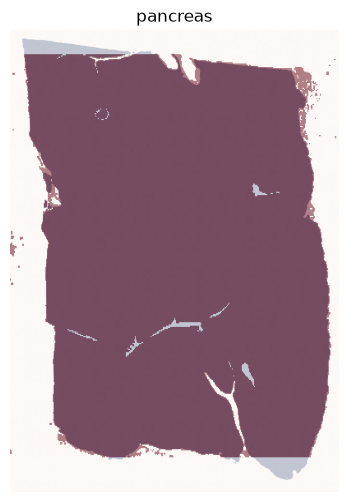

In [9]:
overlay("pancreas")  # change name / bins= and re-run to tune